# 14.1 视觉皮层的构造


---
## 一、引言：为什么视觉任务对AI很难？
虽然早在1996年，IBM深蓝计算机就击败了世界围棋冠军，但直到现在，计算机在完成一些看似简单的视觉任务（比如识别图片中的小猫、理解图像语言）时，仍然很困难。

这是因为：
- 人类的视觉感知发生在大脑的**专门视觉、听觉等感官模块**中，这些模块会在信息到达意识前，对其进行高层次的特征修饰。
- 这种感知过程是**无意识的、高度复杂的**，无法用简单的规则描述。要让AI复现视觉能力，必须模仿生物视觉模块的运作方式。

---
## 二、卷积神经网络（CNN）的起源
卷积神经网络（CNN）的灵感，直接来自**大脑的视觉皮层研究**：
1.  **起源时间与领域**：从20世纪80年代起，CNN就被用于图像识别任务。
2.  **发展与应用**：随着深度网络训练技巧的进步，CNN在图像搜索、自动驾驶、视频分类等视觉任务中表现远超传统方法，也拓展到语音识别、自然语言处理（NLP）等其他领域。
3.  **本章学习目标**：理解CNN的生物学来源、核心构建模块，并学习如何用TensorFlow和Keras实现CNN，同时了解目标检测、语义分割等高级视觉任务。

---
## 三、生物视觉皮层的经典实验（Hubel & Wiesel 1958-1959）
David H. Hubel和Torsten N. Wiesel以猫为对象，完成了一系列里程碑式实验，揭示了视觉皮层的工作机制：
1.  **核心发现：局部感受野（Receptive Field）**
    - 视觉皮层的神经元，只会对**视野中一个小的局部区域（感受野）**的特定视觉刺激做出反应，而非整个画面。
    - 不同神经元的感受野可以互相重叠，平铺覆盖整个视觉区域。
2.  **层级化特征提取**
    - 低层神经元：只对简单的基础特征敏感，比如水平线、垂直线、边缘等。
    - 高阶神经元：通过组合低层神经元的输出，对更复杂的模式（比如形状、物体轮廓）做出反应。
    - 这种层级结构，让大脑可以从简单到复杂，逐步提取图像的所有关键信息。

后续他们用猴子做的实验，进一步完善了这一理论，也让他们获得了1981年诺贝尔生理学或医学奖。

---
## 四、从生物视觉到CNN的演化
1.  **理论影响**：Hubel & Wiesel的研究直接推动了1980年“新认知机”（Neocognitron）的提出，这是CNN的雏形。
2.  **里程碑：LeNet-5**
    1998年Yann LeCun等人发表的论文中，提出了经典的LeNet-5架构，用于手写支票号码识别，它引入了两个至今仍是CNN核心的构建块：
    - **卷积层（Convolutional Layer）**：模仿局部感受野，只连接输入的局部区域，实现特征提取。
    - **池化层（Pooling Layer）**：降低特征维度，减少计算量。

---
## 五、为什么不用全连接网络做图像识别？
传统的全连接深度网络，在MNIST这类小图像上效果不错，但在处理较大图像时完全无法使用：
- **参数爆炸问题**：比如一张100×100像素的图像，输入层就有10000个像素。如果第一层有1000个神经元，就会产生1000万个连接，参数数量极其庞大，极易过拟合，且计算成本极高。
- **CNN的解决思路**：通过**部分连接和权重共享**，大幅减少参数数量，同时保留层级化特征提取的能力。

---

# 14.2 卷积层


---
## 一、卷积层的核心思想
卷积层是CNN的核心构建模块，它直接模仿了生物视觉皮层的**局部感受野**机制，解决了全连接网络参数爆炸的问题。

1.  **局部连接 vs 全连接**
    - 全连接层：每个神经元都和上一层的**所有神经元**相连，参数数量随图像尺寸爆炸式增长。
    - 卷积层：每个神经元只与上一层的**局部感受野**（一小块输入区域）相连，大幅减少了参数数量。
2.  **层级化特征提取**
    - 第一层卷积层：只提取边缘、线条、角点等低阶基础特征。
    - 第二层卷积层：组合第一层的低阶特征，提取形状、纹理等高阶特征。
    - 后续层：继续组合高阶特征，最终识别出完整的物体、场景等复杂模式。
    这种层级结构和生物视觉皮层的工作方式完全一致，也是CNN在图像识别中效果拔群的关键原因之一。

---
## 二、卷积层的关键概念
### 1. 局部感受野（Receptive Field）
- 卷积层中每个神经元，只会对上一层输入的一个**局部矩形区域**做出反应，这个区域就是它的感受野。
- 比如，感受野为 3×3 的神经元，只会和上一层输入中 3×3 区域的像素相连，而不是整个图像。

### 2. 零填充（Zero Padding）
为了让卷积层的输出尺寸和输入尺寸保持一致，通常会在输入图像的四周填充一圈零像素，这就是零填充。
- 作用：避免图像边缘的信息在多次卷积后被“吃掉”，同时可以灵活控制输出特征图的尺寸。

### 3. 步幅（Stride）
步幅是指卷积核在输入图像上滑动时，每次移动的像素距离。
- 步幅为 1：卷积核每次移动1个像素，输出尺寸和输入尺寸（带填充时）几乎相同。
- 步幅为 2：卷积核每次移动2个像素，输出尺寸会缩小一半，相当于对特征图进行下采样，减少计算量。

---
## 三、卷积层的计算逻辑
对于卷积层中第`i`行、第`j`列的神经元：
- 它会连接到上一层输入中，从第 `i×s_h` 到 `i×s_h + f_h - 1` 行，第 `j×s_w` 到 `j×s_w + f_w - 1` 列的区域。
- 其中：
  - `f_h` / `f_w`：感受野的高度/宽度（即卷积核的尺寸）
  - `s_h` / `s_w`：垂直/水平方向的步幅

---
## 四、滤波器（卷积核）
卷积层的神经元权重，通常被称为**滤波器（Filter）**或**卷积核（Kernel）**，它的尺寸和感受野相同。
- 本质：一个小的权重矩阵，通过和输入图像的局部区域做卷积运算，提取特定的特征。
- 例子：一个 7×7 的滤波器，权重设置为中间列全为1、其余为0，它就会对输入中的垂直边缘特别敏感，忽略其他无关信息。
- 一个卷积层通常会包含多个不同的滤波器，分别提取边缘、纹理、颜色等不同类型的特征，最终输出多个特征图（Feature Map）。

---
## 五、卷积层 vs 全连接层的核心优势
| 特性 | 全连接层 | 卷积层 |
| :--- | :--- | :--- |
| **连接方式** | 每个神经元连接所有输入 | 每个神经元只连接局部感受野 |
| **参数数量** | 随图像尺寸指数增长 | 大幅减少，仅和滤波器数量相关 |
| **空间信息保留** | 输入图像被展平为一维，空间信息丢失 | 保持二维结构，保留空间位置关系 |
| **平移不变性** | 不具备 | 具备（同一特征在不同位置都能被检测到） |

---

## 14.2.1 滤波器


---

## 一、核心定义：什么是滤波器？
滤波器（也叫 **卷积核 Kernel** 或 **权重矩阵**）是卷积层中，用于提取特定图像特征的核心组件。
- **本质**：滤波器就是卷积层神经元的**权重集合**，它的尺寸 = 局部感受野（Receptive Field）的尺寸。
- **作用**：在输入图像（或上一层特征图）上滑动，通过卷积运算，把自己擅长检测的特征（如垂直边、水平边、纹理）从图像中提取出来。

---

## 二、滤波器的工作原理：如何提取特征？
滤波器通过**滑动扫描**和**数值计算**来完成特征提取：
1. **滑动扫描**：滤波器在输入图像上按**步幅**移动，每次覆盖一个局部区域（感受野）。
2. **卷积运算**：将滤波器的权重与图像对应区域的像素值进行点积运算（加权求和）。
   - 如果结果值大 → 说明该区域包含了滤波器擅长检测的特征。
   - 如果结果值小或为负 → 说明该区域不包含该特征。
3. **生成特征图**：将所有位置的运算结果组合起来，就形成了一张**特征图（Feature Map）**。特征图上的每一个像素，都代表了原图像对应位置被特定特征检测到的程度。

---

## 三、书中的具体例子：7×7 滤波器案例
书中共展示了两个 7×7 的滤波器例子，直观解释了不同权重如何对应不同特征：

### 1. 垂直边缘检测器
- **权重设置**：
  - 矩阵全为 0。
  - 除了**中间的一列**，全设为 1。
- **效果**：
  - 这个神经元会**完全忽略**感受野内除中心垂直线以外的所有内容。
  - 只要输入图像的对应区域出现垂直的线条或边缘，输出值就会非常大；否则输出为 0。

### 2. 水平边缘检测器
- **权重设置**：
  - 矩阵全为 0。
  - 除了**中间的一行**，全设为 1。
- **效果**：
  - 这个神经元只关注水平方向的线条。
  - 它会忽略除中心水平线以外的所有内容，专门检测水平边缘。

---

## 四、滤波器的“自动学习”能力
书里强调了一个关键点：**滤波器不是手动定义的，而是自动学习出来的。**
- **训练过程**：在神经网络的训练阶段，卷积层会自动不断调整滤波器的权重数值。
- **自动进化**：
  - 底层卷积层：会自动学会检测 **基础特征**（如边缘、角点、色块）。
  - 高层卷积层：会自动组合底层学到的基础特征，检测 **复杂模式**（如眼睛、鼻子、进而整个人脸）。
- **优势**：这让 CNN 能自适应地适应不同的任务（如识别猫、识别狗），而不需要人工手调每一个滤波器。

---

## 五、总结：滤波器的价值
1. **特征提取**：用特定的权重矩阵，从图像中精准定位某一种特征。
2. **参数共享**：一个滤波器在图像的所有位置都使用同一套参数（权重和偏置），这极大减少了网络的参数量，避免过拟合。
3. **平移不变性**：因为参数共享，图像中的特征无论出现在左上角还是右下角，都能被同一个滤波器检测到，这是 CNN 处理图像的核心优势。

---

## 14.2.2 堆叠多个特征图


## 一、核心概念：为什么要堆叠多个特征图？
前面为了简化理解，我们一直把卷积层的输出当成一张二维特征图，但实际上，一个卷积层会包含**多个独立的滤波器**，每个滤波器都会输出一张特征图。这些特征图会像“千层蛋糕”一样堆叠在一起，形成一个三维的特征张量，这就是“堆叠多个特征图”。

- 本质：一个卷积层会同时提取多种不同的特征（边缘、纹理、颜色等），每种特征对应一张特征图。
- 作用：堆叠后的三维特征张量，完整保留了图像的空间结构和多维度特征信息，让后续网络能组合这些特征，识别更复杂的模式。

---
## 二、关键细节：参数共享与跨通道连接
1.  **同一张特征图内的参数共享**
    - 同一张特征图里的所有神经元，共享同一套权重和偏置项（也就是同一个滤波器）。
    - 好处：大幅减少了模型的参数数量，避免过拟合，同时让网络具备“平移不变性”——同一个特征不管出现在图像的哪个位置，都能被检测到。

2.  **跨特征图的连接方式**
    - 卷积层中，每个神经元的感受野，会同时覆盖上一层的**所有特征图（通道）**。
    - 比如，输入是RGB图像（3个通道），卷积层的3×3滤波器，会同时连接3个通道的3×3区域，进行加权求和。
    - 也就是说，滤波器的输入维度会自动和上一层的通道数匹配，最终输出一张新的特征图。

---
## 三、输入通道与输出通道
- **输入通道（Input Channels）**：
  - 对于输入图像来说，通道数就是颜色通道数：灰度图为1，RGB彩色图为3，多光谱卫星图像可以有更多通道。
  - 对于中间卷积层来说，输入通道数就是上一层的滤波器数量。
- **输出通道（Output Channels）**：
  - 等于当前卷积层的滤波器数量，每个滤波器对应一个输出通道（一张特征图）。

---
## 四、卷积层输出的完整形态
- 一个卷积层的输出，是一个三维张量，形状为 `[高度, 宽度, 通道数]`：
  - 高度/宽度：由输入尺寸、滤波器大小、步幅、填充共同决定。
  - 通道数：等于当前卷积层的滤波器数量。
- 举个例子：输入是 `[28, 28, 3]` 的RGB图像，经过一个包含16个3×3滤波器的卷积层（步幅1，填充相同），输出就是 `[28, 28, 16]`，包含16张不同的特征图。

---
## 五、总结：堆叠多个特征图的核心价值
1.  **多特征同时提取**：用多个不同的滤波器，一次性提取图像中的多种关键特征。
2.  **保留三维空间信息**：堆叠后的三维张量，既保留了特征的空间位置，也保留了特征的多样性。
3.  **参数高效利用**：通过参数共享，在大幅减少参数量的同时，让网络具备更强的特征提取能力。

---
需要我帮你整理14.2.3 TensorFlow实现部分的内容，或者给你写一段实现卷积层的Keras代码吗？

## 14.2.3 TensorFlow实现

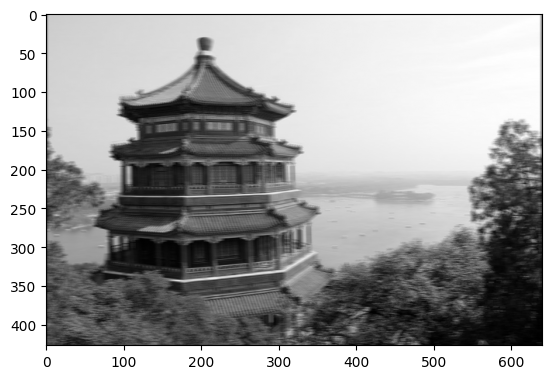

In [1]:
from sklearn.datasets import load_sample_image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load sample images
china = load_sample_image('china.jpg')/255
flower = load_sample_image('flower.jpg')/255
images = np.array([china, flower])
batch_size,height,width,channels = images.shape

# Create 2 filter
filters = np.zeros(shape = (7,7,channels,2),dtype = np.float32)
filters[:,3,:,0] = 1 # vertical line
filters[3,:,:,1] = 1 # horizontal line

outputs = tf.nn.conv2d(images,filters,strides=1,padding='SAME')
plt.imshow(outputs[0,:,:,1],cmap = 'gray')
plt.show()


## 一、图像预处理：归一化
原始图像的每个颜色通道，像素值范围是 `0~255` 的整数。为了适配神经网络的计算，需要先将其缩放到 `0~1` 的浮点数区间，最常用的方法就是**除以255**：
```python
china = load_sample_image('china.jpg') / 255
flower = load_sample_image('flower.jpg') / 255
```
这样可以统一数据尺度，避免大数值输入影响训练稳定性。

---

## 二、TensorFlow 低层API：`tf.nn.conv2d()` 详解
这是TensorFlow中实现卷积运算的底层函数，书中用它手动演示卷积操作。

### 1. 核心参数
| 参数 | 含义 |
| :--- | :--- |
| `images` | 输入图像的小批量数据，是一个 **4D张量**，形状为 `[批量大小, 高度, 宽度, 通道数]` |
| `filter` | 要应用的一组滤波器，也是一个 **4D张量**，形状为 `[滤波器高度, 滤波器宽度, 输入通道数, 输出通道数]` |
| `strides` | 步幅，支持两种格式：<br>- 标量：水平和垂直步幅相同（如`1`）<br>- 4元组：`[1, 垂直步幅, 水平步幅, 1]`，第一个和最后一个元素必须为`1`（对应批量和通道维度的步幅，目前不支持跳过） |
| `padding` | 填充模式，只能是`"SAME"`或`"VALID"` |

### 2. 两种填充模式
- **`padding="SAME"`（零填充）**
  - 卷积层会在输入图像四周自动补零，保证输出特征图的尺寸和输入尺寸相同（当步幅为1时）。
  - 输出尺寸公式：`ceil(输入尺寸 / 步幅)`，向上取整，避免边缘信息丢失。
- **`padding="VALID"`（无填充）**
  - 不补零，直接在原图上滑动卷积核，当步幅大于1时，会忽略输入图像底部和右侧的部分像素。
  - 输出尺寸会比输入小，且无法保证和输入尺寸一致。

---

## 三、Keras高层API：`keras.layers.Conv2D` 层
在实际项目中，我们通常使用Keras的高层API来构建卷积层，它更简洁易用。

### 1. 代码示例
```python
conv = keras.layers.Conv2D(
    filters=32,          # 滤波器数量（输出通道数）
    kernel_size=3,       # 滤波器尺寸（3×3）
    strides=1,           # 步幅
    padding="same",      # 填充模式
    activation="relu"    # 激活函数
)
```

### 2. 关键超参数说明
构建一个卷积层时，你必须定义这些核心参数：
- `filters`：该层包含的滤波器数量，决定了输出通道数。
- `kernel_size`：滤波器的高度和宽度（通常为3×3、5×5等）。
- `strides`：步幅，控制特征图的尺寸缩放。
- `padding`：填充模式，`"same"`或`"valid"`。
- `activation`：激活函数，常用`relu`、`sigmoid`等，为网络引入非线性能力。

---

## 四、手动实现 vs 自动学习
书中提到，示例里是手动定义了7×7的垂直/水平滤波器来演示效果。
但在实际的CNN训练中，滤波器不需要手动设计，网络会在训练过程中自动学习到最适合当前任务的滤波器参数，从而提取对任务最有用的特征。

---


## 14.2.4 内存需求


## 一、核心问题：卷积层的内存占用
虽然卷积层通过局部连接和权重共享，大幅减少了参数数量，但在实际训练中，它依然会消耗大量的内存（RAM），尤其是在**反向传播**阶段。

### 关键原因：反向传播需要保留所有中间结果
在训练过程中，反向传播需要用到正向传播时计算出的所有中间值（比如每个卷积层的输出特征图），才能计算梯度并更新权重。因此，这些中间结果必须全部保存在内存中，导致内存占用激增。

---

## 二、内存占用的具体例子
以书中的例子说明：
- 输入：150×100 的 RGB 图像（3个通道）
- 卷积层：200 个 5×5 的滤波器，步幅为1，填充为 `SAME`
- 输出：200 张 150×100 的特征图

### 1. 参数数量（很少）
$$
(5 \times 5 \times 3 + 1) \times 200 = 15200
$$
（+1 是每个滤波器的偏置项）

### 2. 内存占用（很高）
- 单个样本的特征图数据量：
  $$
  200 \times 150 \times 100 = 3,000,000 \text{ 个浮点数}
  $$
- 若使用 32 位浮点数表示：
  $$
  3,000,000 \times 32 \text{ bit} = 96,000,000 \text{ bit} = 12 \text{ MB}
  $$
- 若训练时的批量大小为 100：
  $$
  12 \text{ MB} \times 100 = 1.2 \text{ GB}
  $$
仅这一层就需要约 1.2GB 的内存。

---

## 三、训练 vs 推理的内存差异
| 阶段 | 内存需求 | 原因 |
| :--- | :--- | :--- |
| **训练阶段** | 极高 | 必须保留所有层的正向传播中间结果，用于反向传播计算梯度。 |
| **推理阶段** | 很低 | 计算完下一层后，上一层的中间结果即可释放，只需保存连续两层的数据。 |

---

## 四、内存不足的解决方案
如果训练时因内存不足失败，可以尝试以下优化方法：
1.  **减小批量大小（Batch Size）**：减少每次训练处理的样本数量，直接降低内存占用。
2.  **调整步幅/网络结构**：使用更大的步幅来降低特征图尺寸，或减少网络层数。
3.  **降低数值精度**：使用 16 位浮点数（如 FP16）代替 32 位浮点数，内存占用直接减半。
4.  **多设备分布式训练**：将 CNN 分配到多个 GPU/设备上并行计算。

---

# 14.3 池化层


---

## 一、核心定义：池化层是什么？
池化层是 CNN 的第二个核心构建块，**目标是对输入图像进行下采样（缩小）**。
- **类比**：它就像把一张高清图压缩成缩略图，虽然变模糊了，但核心结构还在。
- **作用**：减少计算量、降低内存使用、减少参数数量，从而降低过拟合风险。

---

## 二、池化层 vs 卷积层：关键区别
| 特性 | 卷积层 (Convolutional Layer) | 池化层 (Pooling Layer) |
| :--- | :--- | :--- |
| **核心操作** | 加权求和（卷积运算） | **聚合输入**（取最大值/平均值） |
| **权重** | **有权重**（可学习，即滤波器） | **无权重**（固定规则，无状态滑动窗口） |
| **功能** | 提取特征 | **下采样、压缩特征图** |

---

## 三、最常见的池化类型：最大池化（Max Pooling）
书中以 **2×2 池化内核、步幅为 2、无填充** 为例，详细解释了最大池化。

### 1. 工作原理
- **滑动窗口**：在输入特征图上，按步幅滑动一个固定大小的矩形窗口（如 2×2）。
- **取最大值**：在每个窗口内，只保留**数值最大**的那个像素值，丢弃其他值。
- **输出**：输出一张尺寸缩小的特征图。

### 2. 书中例子演示
- **输入窗口**：`[[1, 5], [3, 2]]`
- **计算**：取最大值 5。
- **输出**：`[5]`
- **效果**：输入图像的高度和宽度都变为原来的一半（面积变为 1/4）。

---

## 四、池化层的重要特性（核心考点）
### 1. 独立作用于每个通道
池化层通常独立地作用于输入的**每一个输入通道**。
- **输入**：三维张量 `[高度, 宽度, 通道数]`
- **输出**：三维张量 `[高度/2, 宽度/2, 通道数]`
- **注意**：输出深度（通道数）与输入深度完全相同，不会改变通道数量。

### 2. 引入“变换不变性”（Translation Invariance）
池化层最大的意义在于提供了**一定程度的变换不变性**。
- **含义**：输入图像发生微小的平移、旋转或形变，只要特征还在，池化层的输出依然保持不变。
- **案例**（图14-9）：
    - 图像 A：原始特征。
    - 图像 B：向右移动几个像素。
    - 结果：A 和 B 的最大池化层输出**完全相同**。
- **价值**：这让模型学会了“关注特征是否存在”，而不是“关注特征具体在哪一个像素”，提升了模型的鲁棒性。

---

## 五、最大池化的缺点
任何事物都有两面性，最大池化也有明显的缺陷：

### 1. 信息丢失严重（破坏性）
- 因为只取最大值，75% 的输入信息（2×2窗口里的其他3个值）都被直接丢弃了。
- 在某些对像素位置敏感的任务中，这是不可接受的。

### 2. 缺乏“微小变换不变性”
- 虽然它提供了大范围的不变性，但对于输入的**微小平移**，它会完全改变输出。
- **应用场景限制**：
    - **分类任务**：这是可取的（只要是猫，在哪都是猫）。
    - **语义分割/像素回归**：这是**不可取**的（输入图右移一格，输出图也必须右移一格，需要等变性）。

---

## 六、总结：池化层的意义
1. **降维压缩**：将特征图尺寸减半，大幅减少后续层的计算量。
2. **防止过拟合**：减少参数，降低模型复杂度。
3. **提取关键特征**：通过取最大值，保留最显著的局部特征（如边缘、纹理）。
4. **引入不变性**：提升模型对图像平移、形变的适应能力。

---

## TensorFlow实现

---

## 一、基础池化层：最大池化 & 平均池化
### 1. 最大池化层（Max Pooling）
- **作用**：对输入特征图进行下采样，取池化窗口内的最大值作为输出，降低特征图尺寸，同时引入平移不变性。
- **Keras实现代码**：

In [2]:
# 创建一个2×2内核的最大池化层，步幅默认等于池化核大小（即2），默认使用"valid"填充
from tensorflow import keras
max_pool = keras.layers.MaxPool2D(pool_size = 2)


- **参数说明**：
  - `pool_size`：池化窗口的大小，这里是2×2的窗口。
  - `strides`：步幅，默认和`pool_size`相同，即窗口每次滑动2个像素。
  - `padding`：填充模式，默认是`"valid"`（无填充），也可以设为`"same"`（零填充）。

### 2. 平均池化层（Average Pooling）
- **作用**：和最大池化类似，也是下采样，但它计算的是池化窗口内的平均值。
- **实现代码**：

In [3]:
avg_pool = keras.layers.AvgPool2D(pool_size = 2)

- **两者对比**：
  | 特性 | 最大池化 | 平均池化 |
  | :--- | :--- | :--- |
  | **输出方式** | 取窗口内最大值 | 取窗口内平均值 |
  | **信息保留** | 只保留最显著特征，丢弃其他信息 | 平滑保留窗口内的整体信息 |
  | **计算成本** | 更低 | 略高 |
  | **应用效果** | 现代CNN中更常用，表现通常更好 | 早期网络中更常见，现在较少使用 |


---

## 二、深度池化（Depth-wise Pooling）
- **概念**：不是在空间维度（高度、宽度）上池化，而是在**通道/深度维度**上进行池化，比如在多个特征图之间取最大值。
- **作用**：让模型学习到对特征的旋转、亮度、颜色等变换的不变性，例如不管数字“6”怎么旋转，深度池化都能让模型识别出这是“6”。
- **Keras中没有直接的深度池化层，但可以用TensorFlow底层API实现**：

In [4]:
# 使用tf.nn.max_pool()实现深度最大池化，内核大小和步幅在深度维度为3
output  = tf.nn.max_pool(images,
                         ksize = (1,1,1,3),
                         strides=(1,1,1,3),
                         padding='VALID'
                         )

In [5]:
# 包装在Lambda层
depth_pool = keras.layers.Lambda(
    lambda x: tf.nn.max_pool(x,ksize=(1,1,1,1),strides=(1,1,1,3),padding='VALID')
)

- **注意**：深度池化不常见，且池化核大小必须是输入通道数的约数，否则无法整除。

---

## 三、全局平均池化层（Global Average Pooling, GAP）
- **概念**：一种特殊的池化层，不是对局部窗口池化，而是对**整个特征图的空间维度（高度和宽度）**计算平均值。
- **效果**：每个特征图/通道最终只输出一个值，相当于把整个特征图压缩成一个标量。
- **Keras实现代码**：

In [6]:
# 方式1：直接使用Keras内置层
global_avg_pool = keras.layers.GlobalAvgPool2D()

In [7]:
# 方式2：用Lambda层实现等价效果
global_avg_pool = keras.layers.Lambda(lambda x: tf.nn.reduce_mean(x,axis = [1,2]))

- **特点与应用**：
  - 虽然会丢失大量空间信息，但可以直接作为输出层使用，大幅减少模型参数，防止过拟合。
  - 常用于CNN的末尾，替代全连接层，在分类任务中很常见。

---

## 四、补充：池化层的使用场景
- **常规池化层（MaxPool2D/AvgPool2D）**：放在卷积层之后，用来下采样、降维，减少后续计算量。
- **全局平均池化层**：放在网络的最后，用来将三维特征图压缩为一维向量，作为分类的输出。

# 14.4 CNN架构


## 一、典型CNN的基本结构
一个标准的CNN架构遵循固定的堆叠模式：
`卷积层(+ReLU) → 池化层 → 卷积层(+ReLU) → 池化层 → ... → 全连接层(+ReLU) → 输出层`

- **特征变化规律**：随着网络深入，特征图的**空间尺寸（高/宽）逐渐变小**，但**通道数（特征图数量）逐渐变多**。
- **顶部全连接层**：在卷积池化堆叠完成后，将三维特征图展平为一维向量，再通过几层全连接层，最终输出分类结果（如Softmax层输出类别概率）。

---

## 二、CNN设计的关键经验法则
### 1. 避免使用过大的卷积核
一个常见的错误是直接使用大尺寸卷积核（如5×5、7×7），更优的做法是：
- 用**两层3×3卷积层**代替一层5×5卷积层，用三层3×3代替一层7×7。
- 优势：参数更少、计算量更低，且非线性更强，通常性能更好。
- 例外：输入层的第一个卷积层可以使用较大的核（如7×7），步幅设为2，快速降低图像尺寸，同时不会丢失太多信息。

### 2. 池化后增加滤波器数量
池化层会将特征图的空间尺寸减半，此时我们通常会将下一层的滤波器数量加倍。
- 原因：池化后参数和计算量都大幅降低，此时增加通道数可以在不造成负担的情况下，提取更多高维特征。

---

## 三、Fashion MNIST CNN示例解析
书中给出了一个处理Fashion MNIST数据集的完整CNN代码：

In [8]:
model = keras.models.Sequential([
    keras.layers.Conv2D(64,7,activation = 'relu',padding = 'same',input_shape = [28,28,1]),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128,3,activation = 'relu',padding = 'same'),
    keras.layers.Conv2D(128,3,activation = 'relu',padding = 'same'),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(256,3,activation = 'relu',padding = 'same'),
    keras.layers.Conv2D(256,3,activation = 'relu',padding = 'same'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation = 'relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64,activation = 'relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation = 'softmax')
])




### 模型结构拆解
1.  **输入层**：`Conv2D(64, 7, ...)`，使用64个7×7的滤波器，步幅为1，`padding="same"`，输入为28×28的单通道图像。
2.  **池化与卷积堆叠**：
    - `MaxPooling2D(2)`：将特征图尺寸减半。
    - 后续使用`Conv2D(128, 3)`、`Conv2D(256, 3)`等3×3卷积核，每两次卷积后接一次池化，滤波器数量按池化层数量翻倍。
3.  **全连接层**：
    - `Flatten()`：将三维特征图展平为一维向量。
    - 两层`Dense`层，搭配`Dropout(0.5)`防止过拟合。
    - 最后一层`Dense(10, softmax)`输出10个类别的概率。

该模型在Fashion MNIST测试集上的精度超过92%，远优于全连接网络。

---

## 四、经典CNN架构演进
多年来，ILSVRC ImageNet挑战赛推动了CNN架构的快速发展，错误率从26%降至2.3%，几个里程碑式的架构包括：
- **LeNet-5 (1998)**：最早的经典CNN之一，用于手写数字识别。
- **AlexNet (2012)**：开启了深度学习在计算机视觉领域的浪潮。
- **GoogLeNet (2014)**：引入Inception模块，大幅提升了网络深度和性能。
- **ResNet (2015)**：提出残差连接，解决了深度网络的梯度消失问题，成为后续架构的基础。

---

## 14.4.1 LeNet-5


## 一、核心定位
LeNet-5 是**最广为人知的早期 CNN 架构**，由 **Yann LeCun** 于 **1998 年** 创建。
- **核心用途**：专门用于**手写数字识别（MNIST 数据集）**。
- **历史意义**：它是 CNN 领域的“鼻祖”，证明了卷积神经网络可以直接从像素中学习特征，而无需人工设计。

---

## 二、架构细节拆解（表14-1）
这是一个经典的 **卷积 + 池化 + 全连接** 堆叠结构，我们按从输入到输出的顺序解析：

### 1. 输入层 (In)
- **输入**：$32 \times 32$ 的单通道灰度图像。
- **细节**：MNIST 原始图像是 $28 \times 28$，需先进行 **零填充 (Padding)** 变为 $32 \times 32$，再送入网络。

### 2. 第一层：C1 卷积层
- **类型**：卷积
- **特征图数量**：6
- **内核大小**：$5 \times 5$
- **步幅**：1
- **填充**：无（valid）
- **输出大小**：$28 \times 28$
  （计算：$32 - 5 + 1 = 28$）
- **作用**：用 6 个 $5 \times 5$ 滤波器提取底层特征（边缘、纹理）。

### 3. 第二层：S2 平均池化层
- **类型**：平均池化
- **内核大小**：$2 \times 2$
- **步幅**：2
- **输出大小**：$14 \times 14$
  （计算：$28 / 2 = 14$）
- **特点**：**特殊的可学习池化**。
  - 不仅计算窗口平均值，还乘以一个**可学习的缩放系数**，并加一个**可学习的偏置**，最后应用激活函数。

### 4. 第三层：C3 卷积层
- **类型**：卷积
- **特征图数量**：16
- **内核大小**：$5 \times 5$
- **步幅**：1
- **填充**：无
- **输出大小**：$10 \times 10$
  （计算：$14 - 5 + 1 = 10$）
- **特殊设计**：**稀疏连接**。
  - C3 层的神经元**不是连接到 S2 层的所有 6 个特征图**，而是只连接到 S2 层的 3 或 4 个特征图。
  - 这种设计减少了参数数量，且能让不同滤波器学习不同的特征组合。

### 5. 第四层：S4 平均池化层
- **类型**：平均池化
- **内核大小**：$2 \times 2$
- **步幅**：2
- **输出大小**：$5 \times 5$
  （计算：$10 / 2 = 5$）
- **输出特征图**：16

### 6. 第五层：C5 卷积层
- **类型**：卷积
- **特征图数量**：120
- **内核大小**：$5 \times 5$
- **步幅**：1
- **填充**：无
- **输出大小**：$1 \times 1$
  （计算：$5 - 5 + 1 = 1$）
- **特点**：因为 S4 输出已为 $5 \times 5$，$5 \times 5$ 卷积核覆盖整个输入，这一层等价于 **全连接层**。

### 7. 输出层：F6/F10/Out 全连接层
- **F6**：全连接，输出 84 个值。
- **Out**：全连接，输出 10 个值（对应 0-9 十个数字）。
- **激活函数**：**RBF (径向基函数)**。
  - 计算的是**输入向量与权重向量的欧几里得距离平方**，而非矩阵乘法。
  - 距离越小，代表相似度越高，预测为该数字的概率越大。

---

## 三、设计的核心细节
### 1. 输入预处理
- 虽然 MNIST 是 $28 \times 28$，但网络要求 $32 \times 32$。
- 必须在四周填充 0 像素，这也是图像尺寸随着网络深度不断缩小的原因。

### 2. 池化层的特殊性
- 书中的平均池化层不是“无状态”的，而是**带权重的**（有可学习的系数和偏置），这比标准池化更复杂，性能也更好。

### 3. 连接策略
- **C3 层**：没有使用“密集连接”（上一层所有图连下一层所有图），而是稀疏连接。
- 这不仅限制了参数数量，还让模型能学习更具特异性的特征组合。

### 4. 损失函数与训练
- **损失函数**：使用 **欧几里得距离** 作为输出指标。
- **现代替代**：现在通常使用 **交叉熵 (Cross-Entropy)** 作为损失函数。
  - 交叉熵对预测错误的惩罚更大，梯度更新更快，训练收敛更迅速。

---

一句话总结：**LeNet-5 是现代 CNN 的始祖，它用堆叠的卷积、池化、全连接层成功解决了手写数字识别问题，尽管结构简单且使用了特殊的激活函数（RBF），但奠定了所有后续 CNN 的基础范式。**

---

## 14.4.2 AlexNet



## 一、核心定位与历史意义
AlexNet 是 **2012 年 ImageNet ILSVRC 挑战赛的冠军模型**，由 Alex Krizhevsky、Ilya Sutskever 和 Geoffrey Hinton 开发。
- **里程碑式成果**：将图像分类的前5名错误率从 26% 大幅降低到 17%，远超第二名。
- **历史地位**：它开启了深度学习在计算机视觉领域的浪潮，证明了深度CNN在大规模图像分类任务上的强大能力。
- **架构特点**：相比LeNet-5，AlexNet更大、更深，并且引入了直接堆叠卷积层的设计，不再是“卷积层+池化层”交替的简单模式。

---

## 二、架构细节拆解（表14-2）
### 1. 输入层
- 输入：`227×227×3` 的RGB彩色图像。

### 2. 卷积层与最大池化层
| 层 | 特征图 | 大小 | 内核 | 步幅 | 填充 | 激活 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| C1 | 96 | 55×55 | 11×11 | 4 | valid | ReLU |
| S2 | 96 | 27×27 | 3×3 | 2 | valid | - |
| C3 | 256 | 27×27 | 5×5 | 1 | same | ReLU |
| S4 | 256 | 13×13 | 3×3 | 2 | valid | - |
| C5 | 384 | 13×13 | 3×3 | 1 | same | ReLU |
| C6 | 384 | 13×13 | 3×3 | 1 | same | ReLU |
| C7 | 256 | 13×13 | 3×3 | 1 | same | ReLU |
| S8 | 256 | 6×6 | 3×3 | 2 | valid | - |

### 3. 全连接层与输出层
- F9：全连接层，输出 4096 个值，激活函数为 ReLU。
- F10：全连接层，输出 4096 个值，激活函数为 ReLU。
- Out：全连接层，输出 1000 个值，激活函数为 Softmax（对应ImageNet的1000个类别）。

---

## 三、关键创新与技术细节
### 1. 激活函数：首次大规模使用 ReLU
- 早期CNN多使用tanh或sigmoid激活函数，容易出现梯度消失问题。
- AlexNet首次在大规模深度网络中使用ReLU，解决了深层网络的梯度消失问题，大幅加快了训练速度。

### 2. 正则化与防止过拟合
为了在大规模数据集上防止过拟合，AlexNet引入了两种关键技术：
- **Dropout**：在全连接层F9和F10中，使用了50%的Dropout率，随机让一半神经元失活，避免模型过度依赖特定神经元。
- **数据增强（Data Augmentation）**：通过随机平移、水平翻转、调整亮度等方式生成训练图像的变体，人工扩大训练集规模，增强模型的泛化能力。

### 3. 局部响应归一化（LRN）
- 在C1和C3层的ReLU激活后，引入了局部响应归一化。
- 原理：对同一位置、不同通道的激活值进行竞争抑制，最强的激活会抑制相邻特征图的弱激活，鼓励不同特征图学习差异化的特征，提升泛化能力。
- 公式与实现：可以使用`tf.nn.local_response_normalization()`函数实现，超参数为`r=2, α=0.00002, β=0.75, k=1`。

### 4. 后续变体：ZF Net
- 2013年的ILSVRC挑战赛冠军ZF Net，本质上是调整了超参数（如特征图数量、内核大小、步幅）的AlexNet变体。

---

一句话总结：**AlexNet通过更深的网络结构、ReLU激活、Dropout和数据增强等技术，在ImageNet上取得了突破性成果，奠定了现代深度CNN的基础范式。**

---

## 14.4.3 GoogleNet



## 一、核心定位与历史意义
GoogLeNet 是 **Google 研究院 Christian Szegedy 等人开发的 CNN 架构**，赢得了 **2014 年 ILSVRC 挑战赛冠军**。
- **关键突破**：将图像分类前5名错误率降至 **7%以下**。
- **核心创新**：引入 **Inception（盗梦空间）模块**，让网络在大幅减少参数量的同时变得更深、更高效。
- **参数对比**：参数量仅约 600 万，是 AlexNet（6000万）的 **1/10**，性能却显著提升。

---

## 二、核心创新：Inception 模块
Inception 模块是 GoogLeNet 的灵魂，它让网络能同时使用不同大小的卷积核提取多尺度特征。

### 1. 模块结构
- 输入信号被复制为4路，分别通过不同大小的卷积层和池化层：
  1. `1×1` 卷积层
  2. `3×3` 卷积层（前接一个 `1×1` 卷积降维）
  3. `5×5` 卷积层（前接一个 `1×1` 卷积降维）
  4. `3×3` 最大池化层（后接一个 `1×1` 卷积调整通道）
- 所有分支的输出具有相同的高度和宽度（步幅为1，填充为 `same`），最后沿**深度维度（通道）**拼接在一起（TensorFlow 中用 `tf.concat(axis=3)` 实现）。

### 2. `1×1` 卷积的作用（关键细节）
你可能会疑惑，`1×1` 卷积只能看到单个像素，有什么用？它的三个核心作用是：
1.  **跨通道特征提取**：在深度维度上进行特征组合，识别通道间的关联模式。
2.  **降维（瓶颈层）**：减少特征图数量，降低后续计算量和参数量，避免参数爆炸。
3.  **提升模型能力**：`1×1 + 3×3` / `1×1 + 5×5` 的组合，相当于一个更智能的两层卷积层，能学习更复杂的特征模式。

---

## 三、GoogLeNet 整体架构
1.  **初始降维层**：前两层通过较大的内核和步幅，将图像的高度和宽度除以4，快速降低计算量，同时保留关键信息。
2.  **特征提取层**：卷积层 + 局部响应归一化（LRN），确保网络学习多样化的特征。
3.  **Inception 堆叠**：9个 Inception 模块和最大池化层交错堆叠，深度提取多尺度特征。
4.  **全局平均池化（GAP）**：在网络末尾，用全局平均池化层替代 AlexNet 中的全连接层，直接将每个特征图压缩为一个值。
    - 作用：大幅减少参数量，降低过拟合风险。
5.  **输出层**：1000 个单元的全连接层 + Softmax 激活，输出类别概率。
6.  **辅助分类器**：在第3和第6个 Inception 模块顶部插入两个辅助分类器，它们的损失会被加到总损失中，解决深层网络的梯度消失问题并正则化网络。

---

## 四、后续发展
GoogLeNet 后续发展出多个优化版本，包括 **Inception-v3** 和 **Inception-v4**，它们使用了改进的 Inception 模块，进一步提升了性能。

---

一句话总结：**GoogLeNet 用 Inception 模块实现了“多尺度特征提取+高效降维”，在大幅减少参数量的同时加深了网络，证明了高效的模块设计比单纯堆参数更有效。**

---

## 14.4.4 VGGNet


## 一、核心定位与历史意义
VGGNet 是 **2014 年 ILSVRC 挑战赛的亚军模型**，由牛津大学视觉几何组（VGG）的 Karen Simonyan 和 Andrew Zisserman 开发。
- **关键特点**：架构极其简洁、经典，是后续很多网络设计的基准。
- **核心贡献**：证明了**使用堆叠的 3×3 小卷积核，可以构建更深、性能更强的网络**。

---

## 二、架构核心设计
### 1. 极简堆叠范式
VGGNet 采用了非常规整的模块化结构：
- 重复堆叠 **2~3 个 3×3 卷积层（步幅1，填充`same`）**，然后紧跟一个 **2×2 最大池化层（步幅2）**。
- 这样的组合重复多次，最终形成 16 层（VGG16）或 19 层（VGG19）的深度网络。

### 2. 核心特点：全3×3卷积核
- 整个网络几乎只使用 **3×3 的小卷积核**，没有像 AlexNet 那样使用 11×11、5×5 这类大核。
- 这是因为：**两个连续的 3×3 卷积层，感受野等价于一个 5×5 的卷积层；三个连续的 3×3 卷积层，感受野等价于一个 7×7 的卷积层**。
- 优势：
  1.  **非线性更强**：每一层卷积后都接ReLU激活，多个小核堆叠带来更多非线性变换，特征表达能力更强。
  2.  **参数量更少**：3×3卷积核的参数比大核少很多，大幅降低了模型的参数量和计算量。

### 3. 网络尾部结构
- 卷积池化堆叠完成后，是**两个隐藏层的全连接层**，最后连接输出层。
- 这部分结构和 AlexNet 类似，保持了当时经典的分类头设计。

---

## 三、VGGNet的影响
- 它的规整结构和对小卷积核的验证，深刻影响了后续几乎所有 CNN 的设计。
- 很多模型都借鉴了它的模块化堆叠思想，成为计算机视觉领域的“通用基准架构”之一。

---

一句话总结：**VGGNet 以极简的堆叠方式，用多个3×3小卷积核构建了深层网络，证明了“小核+深度”的强大性能，为后续网络设计提供了清晰的范式。**

---

## 14.4.5 ResNet



## 一、核心定位与历史意义
ResNet（残差网络）由何凯明等人开发，是 **2015 年 ILSVRC 挑战赛的冠军模型**，将前5名错误率降至 **3.6%**。
- **关键突破**：首次成功训练了超过100层的超深卷积神经网络（如ResNet-152），证明了**“深度”是提升模型性能的关键**。
- **核心创新**：提出了**残差学习（Residual Learning）**和**跳跃连接（Skip Connection）**，解决了深层网络训练中的梯度消失/爆炸问题。

---

## 二、核心思想：残差学习与跳跃连接
### 1. 残差学习的原理
常规神经网络的目标是学习一个直接映射：$h(x) = f(x)$
ResNet的目标是学习残差映射：$f(x) = h(x) - x$
其中：
- $x$ 是输入，$h(x)$ 是堆叠层的输出。
- 网络不再直接学习目标函数 $h(x)$，而是学习目标与输入的差（残差）。
- 最终的输出是：$h(x) = x + f(x)$（通过跳跃连接实现）。

### 2. 为什么这有效？
- **解决梯度消失**：信号可以通过跳跃连接直接从输入层传递到深层，梯度也能无阻碍地反向传播，避免了因层数过深导致的梯度消失问题。
- **简化学习任务**：当网络初始化时，权重接近0，堆叠层的输出 $f(x)$ 也接近0，网络的初始状态几乎是一个恒等映射（$h(x) ≈ x$），训练更容易起步。
- **加速收敛**：模型只需要学习输入和目标之间的差异，大大降低了学习难度，收敛速度更快。

---

## 三、核心单元：残差单元（Residual Unit, RU）
ResNet由大量重复的**残差单元**堆叠而成，基础结构如下：
1.  **标准残差单元**：由两个 $3×3$ 卷积层组成，中间包含批量归一化（BN）和ReLU激活，步幅为1，填充为`same`，保持空间维度不变。
2.  **瓶颈残差单元（用于深层ResNet，如ResNet-152）**：为了降低计算量，用三个卷积层代替两个：
    - 第一层：$1×1$ 卷积，降维（如256→64）
    - 第二层：$3×3$ 卷积
    - 第三层：$1×1$ 卷积，升维（如64→256），恢复通道数
    这是一个“瓶颈结构”，大幅减少了参数量和计算量。

---

## 四、ResNet的架构细节
### 1. 整体结构
- **输入层**：与GoogLeNet类似，先使用较大的卷积层和池化层快速降低图像尺寸。
- **残差单元堆叠**：核心部分是大量残差单元的堆叠，中间穿插步幅为2的卷积层来降低特征图尺寸、增加通道数。
- **输出层**：全局平均池化层 + 全连接层 + Softmax激活，输出类别概率。

### 2. 维度匹配问题
当特征图尺寸或通道数发生变化时（如步幅为2），输入 $x$ 和堆叠层的输出 $h(x)$ 形状不匹配，无法直接相加。
- **解决方案**：使用**1×1卷积层**对输入进行调整：
  - 步幅为2，将特征图尺寸减半。
  - 调整通道数，使其与输出通道数一致。
  - 这样调整后的输入再与输出相加，保证形状匹配。

### 3. 经典变体
- **ResNet-34**：由34层组成，使用标准残差单元。
- **ResNet-50/101/152**：使用瓶颈残差单元，层数更深，参数量更少，性能更强。

---

## 五、后续发展与影响
ResNet的思想深刻影响了后续几乎所有深度网络的设计：
- **Inception-v4**：融合了GoogLeNet的Inception模块和ResNet的残差连接，在ImageNet上实现了前5错误率接近3%的成绩。
- 残差连接成为构建超深网络的标准范式，解决了深层网络训练的核心难题。

---

一句话总结：**ResNet通过残差学习和跳跃连接，让超深网络的训练成为可能，极大地推动了深度学习在计算机视觉领域的发展。**

---

## 14.4.6 Xception


## 一、核心定位与历史意义
Xception（**Extreme Inception**，极端Inception）由 Keras 作者 François Chollet 于 **2016年** 提出。
- **本质**：它是 GoogLeNet Inception 架构的**极致变体**，用**深度可分离卷积（Depthwise Separable Convolution）**替代了传统的 Inception 模块。
- **里程碑**：参数量仅为 Inception-v3 的 **1/10**，但在大规模视觉任务（3.5亿张图像、1.7万个类别）上表现远超 Inception-v3，成为当时的SOTA（State-of-the-Art）。

---

## 二、核心创新：深度可分离卷积（Depthwise Separable Convolution）
Xception 之所以强大，在于它彻底重构了卷积操作，将“空间特征”和“通道特征”解耦。

### 1. 常规卷积的痛点
常规卷积核（如 $3\times3$）同时在做两件事：
1. **空间滤波**：在图像上滑动，提取边缘、纹理（空间模式）。
2. **跨通道融合**：同时组合不同通道的信息（如RGB三通道混合）。
Xception 认为这两件事可以分开做，且分开做更好、更省资源。

### 2. 深度可分离卷积的原理（图14-19）
它将卷积拆分为**两步**，完全独立处理空间和通道：
1. **深度卷积（Depthwise Convolution）**：
    - 每个输入通道**独有一个**空间滤波器。
    - 作用：只在空间维度上滑动，提取该通道的边缘/纹理特征。
    - 特点：不进行通道间的混合。
2. **逐点卷积（Pointwise Convolution）**：
    - 使用 $1\times1$ 的常规卷积。
    - 作用：专门负责**跨通道特征融合与组合**（就像Inception模块中的 $1\times1$ 瓶颈层）。

### 3. 为什么 Xception 从 2 个常规卷积开始？
因为深度卷积在通道数太少的层（如输入层）使用时，会丢失太多信息，效果不好。
- **解决方案**：Xception 先用 **2 个常规卷积层** 做初始特征提取，升维并提取基础特征。
- **主体结构**：后续的 34 个卷积层全部使用 **深度可分离卷积**，极大降低了参数和计算量。

---

## 三、Xception 架构特点
1. **极简的 Inception 替代**：
    - Inception 模块是“常规卷积 + 跨通道卷积”的混合体。
    - Xception 模块是“空间卷积 + 跨通道卷积”的纯净分离体。
    - 书中结论：**分离卷积（分别考虑）通常比混合卷积（同时考虑）表现更好。**
2. **高效参数利用**：
    - 相比常规卷积，可分离卷积使用**更少的参数**、**更少的内存**、**更少的计算**。
    - 这使得模型可以在更深、更宽的结构上运行，而不会造成资源爆炸。

---

## 四、与 GoogLeNet/Inception 的关系
Xception 被视为 GoogLeNet 的极致变体：
- 它保留了 Inception-v4 的架构思想，但用深度可分离卷积替换了所有 Inception 模块。
- 它证明了“模块化设计”的极致化可以带来性能飞跃，而不是简单地堆叠更多层。

---

一句话总结：**Xception 通过将卷积拆分为“空间滤波”和“通道融合”两步，极大提升了参数效率，成为比 Inception 更轻量、更强大的经典架构。**



## 14.4.7 SENet


## 一、核心定位与历史意义
SENet（**Squeeze-and-Excitation Network，挤压-激励网络**）是 **2017年ILSVRC挑战赛的冠军架构**，将前5名错误率降至 **2.25%**。
- **核心创新**：通过一个名为 **SE块（Squeeze-and-Excitation Block）** 的轻量级模块，让网络学会**动态调整特征通道的权重**，增强重要特征、抑制无关特征。
- **扩展性**：它不是一个全新的网络，而是可以嵌入到现有架构（如Inception、ResNet）中的通用增强模块，衍生出 **SE-Inception** 和 **SE-ResNet** 等变体。

---

## 二、核心模块：SE块的工作原理
SE块的目标是**专注于深度维度（通道）**，不关心特征的空间位置，只分析哪些通道特征更重要。它分为两步：

### 1. 挤压（Squeeze）：全局信息聚合
- **操作**：对输入特征图执行**全局平均池化（GAP）**。
- **作用**：为每个特征通道生成一个标量值，代表该通道在整个图像中的总体响应强度。
- **例子**：如果输入有256个特征通道，就会输出256个标量值，形成一个长度为256的向量。

### 2. 激励（Excitation）：通道权重学习
- **结构**：由两个全连接层组成：
  1.  **降维层**：神经元数量远少于输入通道数（通常是输入的1/16），用ReLU激活，这一步是“挤压”，将高维向量压缩为低维嵌入。
  2.  **升维层**：神经元数量恢复到原始通道数，用Sigmoid激活，输出一组0~1之间的权重。
- **作用**：学习不同通道之间的依赖关系，生成每个通道的重要性权重。

### 3. 特征重校准
- 将激励层输出的权重向量，与原始输入特征图的每个通道相乘。
- **效果**：
  - 重要的特征通道（权重接近1）被保留甚至增强。
  - 无关或噪声通道（权重接近0）被抑制，降低模型对无关信息的依赖。

---

## 三、工作机制举例
比如在人脸识别任务中：
- SE块会发现，“眼睛”和“嘴巴”的特征通道对识别至关重要，权重会被调高。
- 而“背景”或“阴影”等无关特征通道，权重会被调低。
- 这种动态校准让模型更关注关键特征，提升了鲁棒性和准确率。

---

## 四、SE块的优势
1.  **即插即用**：可以无缝嵌入任何CNN架构（ResNet、Inception等），几乎不增加额外计算成本，却能显著提升性能。
2.  **解决特征冗余**：通过通道权重调整，抑制无效特征，让模型更高效地利用计算资源。
3.  **增强泛化能力**：模型不再被动地接收所有特征，而是主动学习特征的重要性，对噪声和无关信息的鲁棒性更强。

---

一句话总结：**SENet通过SE块让网络学会了“注意力”机制，动态增强重要特征通道，是一种轻量、通用、效果显著的CNN增强技术。**

---

# 14.5 使用Keras实现ResNet-34 CNN

In [9]:
# 首先构建一个ResidualUnit层
class ResidualUnit(keras.layers.Layer):
    def __init__(self,filters,strides=1,activation = 'relu',**kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
        self.main_layers = [
            keras.layers.Conv2D(filters,3,strides = strides,padding = 'same',use_bias = False),
            keras.layers.BatchNormalization(),
            self.activation,
            keras.layers.Conv2D(filters,3,strides = 1,padding = 'same',use_bias = False),
            keras.layers.BatchNormalization(),
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                keras.layers.Conv2D(filters,1,strides = strides,padding = 'same',use_bias = False),
                keras.layers.BatchNormalization()
            ]
    def call(self,inputs):
        Z = inputs
        for layers in self.main_layers:
            Z = layers(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)



## 一、整体结构概览
这是一个继承自 `keras.layers.Layer` 的自定义层，实现了 **ResNet 的基础残差单元**。
它的核心是：
1.  **主路径（main path）**：两层 3×3 卷积 + BN + ReLU
2.  **跳跃连接（skip path）**：可选的 1×1 卷积 + BN（用于维度匹配）
3.  **残差相加**：主路径输出 + 跳跃路径输出，再通过激活函数

---

## 二、逐段代码解析

### 1. 类定义与初始化 `__init__`
```python
class ResidualUnit(keras.layers.Layer):
    def __init__(self, filters, strides=1, activation = 'relu',**kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
```
- `filters`：本单元卷积层的输出通道数。
- `strides`：步幅，当 `strides>1` 时，特征图尺寸会减半（下采样）。
- `activation`：激活函数，默认是 ReLU。
- `super().__init__(**kwargs)`：调用父类 `Layer` 的初始化方法，保证Keras能正确管理该层。

---

### 2. 主路径定义 `self.main_layers`
```python
self.main_layers = [
    keras.layers.Conv2D(filters,3,strides = strides,padding = 'same',use_bias = False),
    keras.layers.BatchNormalization(),
    self.activation,
    keras.layers.Conv2D(filters,3,strides = strides,padding = 'same',use_bias = False),
    keras.layers.BatchNormalization(),
]
```
这是残差单元的“主路径”，包含两层卷积：
1.  `Conv2D(filters, 3, strides=strides, padding='same', use_bias=False)`
    - 3×3 卷积核，步幅为 `strides`，`padding='same'` 保证输出尺寸不变（当 `strides=1` 时）。
    - `use_bias=False`：因为后面接了BN层，BN本身包含偏置项，所以卷积层不需要额外偏置。
2.  `BatchNormalization()`：批量归一化，加速训练，防止梯度消失/爆炸。
3.  `self.activation`：ReLU激活函数，引入非线性。
4.  第二层 `Conv2D` 和 `BatchNormalization`：和第一层结构相同，完成特征提取。

> 注意：这里有一个小细节，两层卷积的步幅都设为了 `strides`，这会导致当 `strides>1` 时，特征图被下采样两次，尺寸变为原来的 1/4。标准ResNet的做法是：**仅在第一层卷积设置步幅 `strides`，第二层步幅固定为1**，避免过度下采样。

---

### 3. 跳跃连接定义 `self.skip_layers`
```python
self.skip_layers = []
if strides > 1:
    self.skip_layers = [
        keras.layers.Conv2D(filters,1,strides = strides,padding = 'same',use_bias = False),
        keras.layers.BatchNormalization()
    ]
```
这是“跳跃连接”的路径，只有当 `strides>1` 时才启用：
- `Conv2D(filters, 1, strides=strides, padding='same', use_bias=False)`：
  - 1×1 卷积核，步幅为 `strides`，作用是：
    1.  **调整通道数**：当本单元输出通道数和输入通道数不同时，1×1卷积可以将输入通道数调整为和输出一致。
    2.  **调整空间尺寸**：步幅 `strides` 会将特征图尺寸减半，和主路径的输出尺寸匹配。
- `BatchNormalization()`：和主路径保持一致，保证相加时数据分布相同。

---

### 4. 前向传播 `call` 方法
```python
def call(self,inputs):
    Z = inputs
    for layers in self.main_layers:
        Z = layers(Z)
    skip_Z = inputs
    for layer in self.skip_layers:
        skip_Z = layer(skip_Z)
    return self.activation(Z + skip_Z)
```
1.  主路径计算：
    - `Z = inputs`：将输入赋值给 `Z`。
    - 遍历 `self.main_layers`，依次通过所有层，得到主路径的输出 `Z`。
2.  跳跃路径计算：
    - `skip_Z = inputs`：将输入赋值给 `skip_Z`。
    - 遍历 `self.skip_layers`，如果 `strides>1`，就通过1×1卷积和BN，否则直接使用输入。
3.  残差相加与激活：
    - `Z + skip_Z`：主路径输出和跳跃路径输出相加，实现残差连接。
    - `self.activation(...)`：通过激活函数（ReLU），得到最终输出。



In [10]:
# 使用Sequential模型来构建ResNet-34
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(64,7,strides = 2,padding = 'same',input_shape = [224,224,3],use_bias = False))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'))
prev_filters = 64
for filter  in [64]*3+[128]*4+[256]*6+[512]*3:
    strides = 1 if filter == prev_filters else 2
    model.add(ResidualUnit(filter,strides))
    prev_filters = filter
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10,activation = 'softmax'))



## 一、整体架构概览
这是一个用 Keras `Sequential` 构建的标准 **ResNet-34** 模型，结构可以分为 4 个部分：
1.  **输入与初始降维层**
2.  **残差单元堆叠（核心部分）**
3.  **全局平均池化层**
4.  **输出全连接层**

---

## 二、逐段代码解析

### 1. 初始层：输入与降维
```python
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(64, 7, strides=2, padding="same", input_shape=[224, 224, 3], use_bias=False))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
```
这部分是 ResNet 的“入口”，作用是快速降低图像尺寸并提取底层特征：
- `Conv2D(64, 7, strides=2, padding="same")`：
  - 用 `7×7` 的大卷积核，步幅为2，`padding="same"`，将输入图像 `224×224×3` 变为 `112×112×64`。
  - 大核可以快速降低尺寸，同时保留关键信息。
- `BatchNormalization()`：批量归一化，稳定训练。
- `Activation('relu')`：引入非线性。
- `MaxPool2D(pool_size=3, strides=2, padding="same")`：
  - 3×3最大池化，步幅2，将尺寸从 `112×112` 进一步缩小到 `56×56`。
- 这一层结束后，特征图尺寸变为 `(56, 56, 64)`。

---

### 2. 核心部分：残差单元堆叠
```python
prev_filters = 64
for filter in [64]*3 + [128]*4 + [256]*6 + [512]*3:
    strides = 1 if filter == prev_filters else 2
    model.add(ResidualUnit(filter, strides))
    prev_filters = filter
```
这是 ResNet-34 的灵魂，我们来拆解：

#### （1）残差单元数量与通道变化
`[64]*3 + [128]*4 + [256]*6 + [512]*3` 定义了16个残差单元的通道配置，对应标准 ResNet-34：
- 3个 `64` 通道的单元（保持通道不变）
- 4个 `128` 通道的单元（通道从64→128）
- 6个 `256` 通道的单元（通道从128→256）
- 3个 `512` 通道的单元（通道从256→512）
合计 `3+4+6+3=16` 个残差单元，每个单元含2个卷积层，加上初始卷积层，正好构成34层网络。

#### （2）步幅控制逻辑
`strides = 1 if filter == prev_filters else 2` 是关键的控制逻辑：
- 当 `filter == prev_filters`（通道数不变）：步幅为1，特征图尺寸不变。
- 当 `filter != prev_filters`（通道数翻倍）：步幅为2，特征图尺寸减半，同时通道数翻倍。

#### （3）尺寸变化过程
- 初始池化后：`(56, 56, 64)`
- 经过3个64通道单元：尺寸保持 `56×56`，通道保持64。
- 进入128通道单元：步幅为2，尺寸变为 `28×28`，通道变为128。
- 进入256通道单元：步幅为2，尺寸变为 `14×14`，通道变为256。
- 进入512通道单元：步幅为2，尺寸变为 `7×7`，通道变为512。
最终残差单元部分结束时，特征图尺寸为 `(7, 7, 512)`。

---

### 3. 全局平均池化层
```python
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Flatten())
```
这部分的作用是将三维特征图压缩为一维向量：
- `GlobalAvgPool2D()`：对 `7×7×512` 的特征图，每个通道求平均值，输出一个长度为512的一维向量。
- 相比直接 `Flatten()`，全局平均池化可以大幅减少参数，降低过拟合风险。
- `Flatten()`：这里是冗余的（`GlobalAvgPool2D` 已经输出一维向量），但加上也不会报错，只是多余的一步。

---

### 4. 输出全连接层
```python
model.add(keras.layers.Dense(10, activation='softmax'))
```
- 全连接层，输出10个值，`softmax` 激活函数，对应10个类别的分类任务（如Fashion MNIST、CIFAR-10）。

---

## 三、关键细节与ResNet的设计思想
1.  **残差连接的作用**：通过 `ResidualUnit` 中的跳跃连接，解决了深层网络的梯度消失问题，让模型可以训练到34层甚至更深。
2.  **通道数翻倍与尺寸减半**：每经过一组单元，通道数翻倍、尺寸减半，这样既可以控制计算量，又能让高层特征图包含更多语义信息。
3.  **无全连接层的池化**：用全局平均池化替代传统的全连接层，是ResNet的一个重要优化，减少了大量参数。

---

## 四、可以做的优化点（可选）
1.  **移除冗余的 `Flatten()`**：`GlobalAvgPool2D` 已经输出一维向量，`Flatten()` 是多余的，可以删掉。
2.  **修改输出类别数**：如果数据集不是10分类，比如ImageNet是1000分类，需要把 `Dense(10)` 改成 `Dense(1000)`。
3.  **添加Dropout**：在全连接层前添加 `Dropout(0.5)` 可以进一步防止过拟合。

---

## 五、运行 `model.summary()` 看看结果
你可以运行 `model.summary()` 查看完整的模型结构，确认各层的形状变化：
```python
model.summary()
```
可以看到清晰的尺寸和通道变化，从而对ResNet的结构有更直观的理解。

---

# 14.6 使用keras的预训练模型

In [11]:
# 加载在ImageNet上预训练的ResNet-50模型
model = keras.applications.resnet50.ResNet50(weights = 'imagenet')


In [12]:
# 调整之前加载的图像大小
images_resized = tf.image.resize(images,[224,224])

In [13]:
# 对图像进行预处理，缩放
inputs = keras.applications.resnet50.preprocess_input(images_resized*255)

In [14]:
# 使用预训练的模型进行预测
Y_proba = model.predict(inputs)

1/1 [==============================] - 2s 2s/step


In [15]:
# 显示前K个预测
top_K = keras.applications.resnet50.decode_predictions(Y_proba,top = 3)
for image_index in range(len(images)):
    print('Image #{}'.format(image_index))
    for class_id,name,y_proba in top_K[image_index]:
        print('   {} - {:125}{:.2f}%'.format(name,class_id,y_proba*100))
    print()

Image #0
   bell_cote - n02825657                                                                                                                    82.35%
   palace - n03877845                                                                                                                    6.75%
   monastery - n03781244                                                                                                                    4.19%

Image #1
   honeycomb - n03530642                                                                                                                    49.81%
   stinkhorn - n13040303                                                                                                                    33.96%
   bee - n02206856                                                                                                                    4.35%



# 14.7 迁移学习预训练模型

In [16]:
# 对花的图片进行分类，并使用预先训练的Xception模型
import tensorflow_datasets as tfds

datasets,info = tfds.load('tf_flowers',as_supervised=True,with_info=True)
dataset_size = info.splits['train'].num_examples# 3670
class_names = info.features['label'].names
n_classes = info.features['label'].num_classes

In [17]:
import tensorflow_datasets as tfds

# 按 10% / 15% / 75% 划分
test_set = tfds.load('tf_flowers', split='train[:10%]', as_supervised=True)
valid_set = tfds.load('tf_flowers', split='train[10%:25%]', as_supervised=True)  # 10%~25% 是15%
train_set = tfds.load('tf_flowers', split='train[25%:]', as_supervised=True)     # 25%之后是75%

In [18]:
# 预处理图像
def preprocess(image,label):
    resized_image = tf.image.resize(image,[224,224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image,label

In [19]:
# 用预处理函数处理所有的三个数据集·，对训练集进行乱序，并对所有数据集添加批量处置和预处理
batch_size = 32
train_set = train_set.shuffle(1000)
train_set = train_set.map(preprocess).batch(batch_size).prefetch(1)
valid_set = valid_set.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set.map(preprocess).batch(batch_size).prefetch(1)


In [20]:
# 加载一个在ImageNet上预训练的Xception模型
base_model = keras.applications.xception.Xception(weights = 'imagenet', include_top = False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes,activation = 'softmax')(avg)
model = keras.Model(inputs = base_model.input, outputs = output)

In [21]:
# 冻结预训练层的权重
for layer in base_model.layers:
    layer.trainable = False

In [22]:
# 编译模型并开始训练
optimizer = keras.optimizers.legacy.SGD(learning_rate = 0.2,momentum=0.9,decay = 0.01)
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])
history = model.fit(train_set,epochs = 5,validation_data = valid_set)

Epoch 1/5



86/86 [==============================] - 79s 875ms/step - loss: 1.8556 - accuracy: 0.7867 - val_loss: 1.2484 - val_accuracy: 0.8475
Epoch 2/5
86/86 [==============================] - 72s 842ms/step - loss: 0.5688 - accuracy: 0.9041 - val_loss: 0.9487 - val_accuracy: 0.8693
Epoch 3/5
86/86 [==============================] - 70s 811ms/step - loss: 0.2733 - accuracy: 0.9350 - val_loss: 0.8128 - val_accuracy: 0.8566
Epoch 4/5
86/86 [==============================] - 77s 899ms/step - loss: 0.1392 - accuracy: 0.9648 - val_loss: 0.7608 - val_accuracy: 0.8730
Epoch 5/5
86/86 [==============================] - 75s 878ms/step - loss: 0.0883 - accuracy: 0.9753 - val_loss: 0.7614 - val_accuracy: 0.8584


In [24]:
# 这次使用低得多的学习率来避免损失预训练的权重
for layer in base_model.layers:
    layer.trainable = True

optimizer = keras.optimizers.legacy.SGD(learning_rate = 0.01,momentum=0.9,decay = 0.01)
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])
history = model.fit(train_set,epochs = 5,validation_data = valid_set)

Epoch 1/5
86/86 [==============================] - 329s 4s/step - loss: 0.4287 - accuracy: 0.8576 - val_loss: 0.6889 - val_accuracy: 0.8584
Epoch 2/5
86/86 [==============================] - 552s 6s/step - loss: 0.0624 - accuracy: 0.9800 - val_loss: 0.3678 - val_accuracy: 0.9038
Epoch 3/5
86/86 [==============================] - 499s 6s/step - loss: 0.0289 - accuracy: 0.9909 - val_loss: 0.3779 - val_accuracy: 0.9093
Epoch 4/5
86/86 [==============================] - 420s 5s/step - loss: 0.0245 - accuracy: 0.9920 - val_loss: 0.3600 - val_accuracy: 0.9093
Epoch 5/5
86/86 [==============================] - 544s 6s/step - loss: 0.0114 - accuracy: 0.9975 - val_loss: 0.3672 - val_accuracy: 0.9111


In [25]:
# 分类和定位
#定位图片中的物体可以表示为回归任务：预测物体周围的边界框。可以预测物体中心的水平坐标和垂直坐标，还有其高度和宽度
base_model = keras.applications.xception.Xception(weights = 'imagenet', include_top = False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = keras.layers.Dense(n_classes,activation = 'softmax')(avg)
loc_output = keras.layers.Dense(4)(avg)
model = keras.Model(inputs = base_model.input, outputs = [class_output,loc_output])
model.compile(loss = ['sparse_categorical_crossentropy','mse'],
              loss_weights = [0.8,0.2],
              optimizer = optimizer,metrics = ['accuracy'])



# 14.8 分类和定位（Classification and Localization）
这一节的核心是：在完成图像分类的基础上，增加**物体定位（预测物体在图中的位置）**的任务。

---

## 一、核心任务：从“分类”到“分类+定位”
- **分类任务**：输出一个类别（如“这是一朵花”）。
- **定位任务**：额外输出物体在图片中的位置，通常用一个**边界框（bounding box）**表示。
- 这是一个**多任务学习**问题：同时训练两个目标。

---

## 二、边界框的表示方式
定位的目标是预测物体的边界框，通常用4个值来表示：
- `x_center`：物体中心的水平坐标
- `y_center`：物体中心的垂直坐标
- `width`：物体的宽度
- `height`：物体的高度

> 注意：为了模型训练稳定，通常会把这些值归一化到 `[0,1]` 区间。
> 而且为了减少大框和小框的误差差异，会预测 `sqrt(width)` 和 `sqrt(height)`，而不是直接预测宽高。

---

## 三、模型结构改造：一个输入，两个输出
在已有的分类模型（如Xception）基础上，只需做很小的修改，就能实现“分类+定位”：

### 1. 模型构建代码
```python
# 1. 加载预训练的Xception模型，去掉顶层分类器
base_model = keras.applications.xception.Xception(weights="imagenet", include_top=False)

# 2. 全局平均池化层，将特征图压缩为向量
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)

# 3. 分类头（和原来一样）
class_output = keras.layers.Dense(n_classes, activation="softmax")(avg)

# 4. 定位头：输出4个值（x_center, y_center, w, h）
loc_output = keras.layers.Dense(4)(avg)

# 5. 构建多输出模型
model = keras.Model(inputs=base_model.input, outputs=[class_output, loc_output])
```

### 2. 模型编译
因为是多任务，需要同时优化两个损失函数：
```python
model.compile(
    loss=["sparse_categorical_crossentropy", "mse"],  # 分类用交叉熵，定位用均方误差
    loss_weights=[0.8, 0.2],  # 给两个损失不同的权重，这里更看重分类任务
    optimizer=optimizer,
    metrics=["accuracy"]
)
```
- `sparse_categorical_crossentropy`：分类任务的损失
- `mse`（均方误差）：边界框回归任务的损失
- `loss_weights`：可以根据你的需求调整两个任务的重要性

---

## 四、关键问题：数据集标注
要训练定位模型，你的数据集必须包含**边界框标签**。

1.  **现状**：你用的花朵数据集 `tf_flowers` 只有类别标签，没有边界框，所以无法直接训练定位任务。
2.  **如何获取边界框标签？**
    - **手动标注**：使用开源工具如 `LabelImg`、`OpenLabeler` 等，自己为每张图片画框。
    - **众包标注**：如果数据量大，可以使用平台如 Amazon Mechanical Turk，但成本较高。
3.  **数据格式**：训练集的每个样本都必须是 `(图片, 类别标签, 边界框)` 的三元组。

---

## 五、边界框的评估指标：IoU（交并比）
MSE损失只能用于训练，不能很好地评估定位效果。评估时，最常用的指标是**交并比（Intersection over Union, IoU）**：
- 计算预测框和真实框的交集面积，除以它们的并集面积。
- `IoU = 1` 表示预测框和真实框完全重合，`IoU = 0` 表示完全不重叠。
- 在Keras中，可以用 `tf.keras.metrics.MeanIoU` 来实现。

---

## 六、与“物体检测”的区别
- **分类+定位**：假设图片中只有一个主要物体，输出一个类别和一个边界框。
- **物体检测（14.9节）**：图片中可能包含多个物体，需要同时识别所有物体的类别和位置。

---

### 一句话总结
14.8节的核心是：**通过在预训练分类模型上增加一个回归输出头，实现“分类+定位”的多任务学习，关键是需要带边界框标注的数据集和MSE损失。**

---

# 14.9 物体检测



物体检测的核心任务是：**同时识别图像中所有物体的类别和位置（边界框）**，解决“多物体+多位置”的问题。

---

## 一、传统方法：滑动窗口检测（Sliding Window）
这是早期的物体检测思路，也是这一节的引入内容。

### 1. 基本流程
1.  **滑动窗口**：用训练好的分类+定位模型，在图像上以不同大小（如3×3、4×4）和步幅滑动窗口。
2.  **多次检测**：对每个窗口执行一次预测，得到类别、置信度和边界框。
3.  **后处理**：消除重复检测的边界框。

### 2. 存在的问题
- 同一物体被多次检测，产生大量重叠的边界框。
- 多次运行CNN，计算量极大，速度非常慢。

---

## 二、关键后处理：非极大值抑制（NMS）
为了解决滑动窗口的重复检测问题，引入了**非极大值抑制（Non-Maximum Suppression, NMS）**，流程如下：

1.  **过滤低置信度框**：
    - 给模型添加一个**置信度（objectness score）**输出，用sigmoid激活。
    - 删除置信度低于阈值（如0.5）的边界框，只保留模型认为“确实有物体”的框。

2.  **保留最高分框，抑制重叠框**：
    - 找出当前所有框中置信度最高的那个框。
    - 删除所有与它IoU（交并比）大于某个阈值（如0.6）的其他框，认为它们检测的是同一个物体。

3.  **重复迭代**：
    - 重复步骤2，直到没有更多的框需要删除，最终每个物体只保留一个边界框。

---

## 三、改进方案：全卷积网络（FCN）
为了解决滑动窗口速度慢的问题，引入了**全卷积网络（Fully Convolutional Network, FCN）**，这是物体检测和语义分割的重要基础。

### 1. 核心思想
- 用**卷积层替代CNN顶部的全连接层**，让模型可以接受任意尺寸的输入图像。
- 输出不再是单一的分类结果，而是一个**特征图**，每个位置对应原图的一个区域，这样可以一次前向传播完成所有位置的预测，大幅提升速度。

### 2. 历史意义
FCN由Jonathan Long等人在2015年提出，最初用于语义分割，后来被广泛应用于物体检测（如YOLO、SSD）中，是现代计算机视觉模型的重要基石。

---

## 四、与“分类+定位”的区别
| 任务 | 特点 |
| :--- | :--- |
| **分类+定位** | 假设图片中只有一个主要物体，输出一个类别和一个边界框 |
| **物体检测** | 图片中可能包含多个物体，需要同时识别所有物体的类别和位置 |

---

### 一句话总结
14.9节的核心是：**从单物体分类+定位，扩展到多物体检测，介绍了早期的滑动窗口方法、非极大值抑制（NMS）后处理，以及为解决速度问题而提出的全卷积网络（FCN）。**

---

## 14.9.1 全卷积网络



## 全卷积网络（Fully Convolutional Network, FCN）
FCN是现代物体检测和语义分割的基础，它的核心思想是：**用卷积层替代CNN顶部的全连接层，让模型可以处理任意尺寸的输入图像，并且一次前向传播完成所有位置的预测**。

---

## 一、FCN的核心原理：卷积层替代全连接层
### 1. 为什么要替换？
传统CNN的全连接层有一个致命缺点：**需要固定大小的输入图像**。
- 比如，一个输入为 `7×7×200` 的全连接层，只能接受这个尺寸的特征图。
- 要处理不同大小的图像，必须把图像裁剪或缩放到固定尺寸，既麻烦又会损失信息。

### 2. 怎么替换？
将一个全连接层转换为卷积层，需要满足3个条件：
1.  **滤波器数量**：等于全连接层的神经元数。
2.  **滤波器大小**：等于输入特征图的宽高（如输入是 `7×7`，滤波器就是 `7×7`）。
3.  **填充方式**：使用 `valid` 填充（无填充）。

### 3. 转换效果
- 全连接层输出：`(batch_size, num_neurons)` 一维向量。
- 替换后的卷积层输出：`(batch_size, 1, 1, num_neurons)` 四维张量。
- 数值上，两者完全等价，但卷积层可以处理任意尺寸的输入特征图。

---

## 二、FCN的关键优势：处理任意尺寸输入
当你把CNN的全连接层都替换成卷积层后，模型就变成了全卷积网络：
- 输入图像可以是任意尺寸（比如 `224×224`、`448×448` 都可以）。
- 输出不再是单一的预测结果，而是一个**特征图**，每个位置对应原图的一个区域的预测。

### 举个例子
假设一个分类模型的输出是10个类别，全连接层输出是 `(batch, 10)`。
- 换成卷积层后，输入 `224×224` 图像，输出是 `(batch, 1, 1, 10)`。
- 输入 `448×448` 图像，输出是 `(batch, 8, 8, 10)`，也就是 `8×8` 个位置，每个位置都有10个类别的预测。

这相当于：**用一次前向传播，完成了对图像所有位置的滑动窗口预测**，效率比传统的滑动窗口高得多。

---

## 三、FCN在物体检测中的应用
FCN的思想被广泛应用在物体检测中，比如YOLO、SSD等模型：
1.  **一次完成全图预测**：模型一次前向传播，就能得到图像上所有网格位置的类别、置信度和边界框预测。
2.  **大幅提升速度**：避免了传统滑动窗口的多次重复计算，让实时物体检测成为可能。
3.  **后续处理更方便**：输出的特征图可以直接对接NMS（非极大值抑制），过滤重复的边界框。

---

## 四、与传统滑动窗口的对比
| 方法 | 优点 | 缺点 |
| :--- | :--- | :--- |
| **传统滑动窗口** | 直观简单 | 多次运行CNN，计算量大，速度极慢 |
| **FCN** | 一次前向传播完成全图预测，速度极快 | 模型结构需要改造，理解门槛稍高 |

---

### 一句话总结
FCN的核心就是：**用卷积层替代全连接层，让模型可以处理任意尺寸的输入，并且一次前向传播完成所有位置的预测，是现代物体检测和语义分割的基石。**

---


## 14.9.2 YOLO



## 14.9.2 YOLO（You Only Look Once）
YOLO是一种**单阶段、实时物体检测**架构，以速度快、精度高著称，是现代物体检测的标杆模型之一。

---

## 一、核心思想：一次前向传播完成检测
YOLO的核心是：**将图像划分为网格，一次前向传播同时预测每个网格的类别、置信度和边界框**，因此得名“You Only Look Once”。

### 1. 网格划分
- 输入图像被划分为 `S×S` 的网格（如 `13×13` 或 `19×19`）。
- 每个网格单元负责预测中心落在该单元内的物体。

### 2. 每个网格的输出
YOLOv3中，每个网格单元输出多个信息：
- **多个边界框**（通常是3个），每个框包含：
  - `(x, y)`：边界框中心相对于网格单元的偏移（归一化到 `[0,1]`）。
  - `w, h`：边界框的宽高（基于先验锚框的缩放比例）。
  - `confidence`：置信度（该框包含物体的概率）。
- **类别概率**：该物体属于每个类别的概率。

---

## 二、关键改进：锚框（Anchor Boxes）
为了提高边界框预测的准确性，YOLO引入了**锚框（先验边界框）**：
1.  **生成锚框**：
    - 对训练集中所有边界框的宽高做K-Means聚类，得到几个典型的宽高比（锚框）。
    - 例如，训练集中行人、车辆、花朵的典型尺寸，作为不同的锚框。
2.  **预测缩放因子**：
    - 模型不直接预测边界框的宽高，而是预测锚框的缩放因子。
    - 最终边界框 = 锚框尺寸 × 预测的缩放因子。
3.  **好处**：
    - 模型更容易学习到合理的边界框尺寸，训练更快、收敛更稳定。
    - 每个网格可以预测不同尺寸的物体，提升检测能力。

---

## 三、多尺度训练
YOLO使用不同尺寸的输入图像进行训练（如 `320×320`、`416×416`、`608×608`）：
- 较小尺寸：速度快，但对小物体检测精度较低。
- 较大尺寸：精度高，但速度较慢。
- 可以根据实际需求，选择合适的输入尺寸。

---

## 四、评估指标：均值平均精度（mAP）
物体检测中常用的评估指标是**均值平均精度（mAP）**：
1.  **精度-召回率曲线**：对每个类别，绘制不同置信度阈值下的精度和召回率曲线。
2.  **平均精度（AP）**：计算精度-召回率曲线下的面积。
3.  **均值平均精度（mAP）**：对所有类别的AP取平均值。
4.  **IoU阈值**：通常以IoU=0.5为阈值，判断预测框是否为正例，记为 `mAP@0.5`。

---

## 五、与其他检测模型的对比
- **YOLO**：单阶段检测，速度快，适合实时场景。
- **SSD**：也是单阶段检测，多尺度特征图预测，精度和速度都不错。
- **Faster R-CNN**：双阶段检测，先提候选框再分类，精度高但速度慢。

---

### 一句话总结
YOLO的核心是：**通过网格划分、锚框和多尺度训练，实现一次前向传播同时预测所有物体的类别和边界框，是速度和精度平衡得很好的实时物体检测模型。**

---


---

# 14.10 语义分割（Semantic Segmentation）
语义分割是比物体检测更精细的任务，目标是**为图像中的每个像素分配一个类别**，实现“像素级”的理解。

---

## 一、任务定义：从“框物体”到“分像素”
- **分类/定位**：输出一个类别+一个边界框，只能知道物体大概位置。
- **物体检测**：输出多个类别+多个边界框，能知道多个物体的位置。
- **语义分割**：输出一张和原图一样大的掩码图，每个像素都有类别标签（如道路、汽车、行人、天空）。
  - 注意：语义分割不区分同类物体，比如所有汽车都会被标为同一个类别，不会区分“车A”和“车B”。

---

## 二、核心难点：空间分辨率丢失
传统CNN（如ResNet）通过池化层降低尺寸，会丢失空间细节。比如：
- 输入 `224×224` 的图像，经过总步幅为32的CNN，输出特征图只有 `7×7`，无法还原每个像素的类别。
- 直接用低分辨率特征图做分割，会导致结果非常粗糙，物体边缘模糊。

---

## 三、经典解决方案：FCN + 上采样 + 跳跃连接
Jonathan Long等人在2015年提出的**全卷积网络（FCN）**，是语义分割的里程碑方法，解决了分辨率丢失问题。

### 1. 上采样（Upsampling）
把低分辨率的特征图放大回原图尺寸，使用**转置卷积（反卷积）**层实现：
- 转置卷积层可以学习如何将小特征图放大，而不是简单的插值。
- 在Keras中，对应 `keras.layers.Conv2DTranspose` 层。

### 2. 跳跃连接（Skip Connections）
为了恢复细节，FCN会从CNN的中间层引出跳跃连接：
- 比如，先把顶层特征图放大2倍，再和底层高分辨率特征图相加，逐步恢复细节。
- 这样可以同时利用高层语义信息和低层空间细节，让分割边缘更清晰。

---

## 四、进阶：实例分割（Instance Segmentation）
语义分割的扩展，是更精细的任务：
- 语义分割：只区分类别，不区分同类个体。
- 实例分割：不仅区分类别，还要区分每个不同的物体（比如“车1”、“车2”）。
- 代表模型：**Mask R-CNN**，在Faster R-CNN的基础上，为每个检测框生成像素级掩码。

---

## 五、总结：从粗到细的计算机视觉任务
| 任务 | 输出 | 精细度 |
| :--- | :--- | :--- |
| 图像分类 | 一个类别标签 | 最粗 |
| 分类+定位 | 一个类别+一个边界框 | 较粗 |
| 物体检测 | 多个类别+多个边界框 | 中等 |
| 语义分割 | 每个像素的类别标签 | 精细 |
| 实例分割 | 每个像素的类别+实例标签 | 最精细 |

---

### 一句话总结
语义分割的核心是：**通过FCN、上采样和跳跃连接，为图像中每个像素分配类别标签，实现像素级的场景理解，是比物体检测更精细的计算机视觉任务。**

